In [3]:
import pandas as pd

# Memuat dataset
df = pd.read_csv('/content/ravenstack_subscriptions.csv')

# Menampilkan dimensi data (Baris x Kolom)
print("Shape Dataset:", df.shape)

# Menampilkan tipe data setiap kolom
print("\n--- Tipe Data ---")
print(df.dtypes)

# Menampilkan 5 baris pertama
print("\n--- 5 Baris Pertama ---")
display(df.head())

Shape Dataset: (5000, 14)

--- Tipe Data ---
subscription_id      object
account_id           object
start_date           object
end_date             object
plan_tier            object
seats                 int64
mrr_amount            int64
arr_amount            int64
is_trial               bool
upgrade_flag           bool
downgrade_flag         bool
churn_flag             bool
billing_frequency    object
auto_renew_flag        bool
dtype: object

--- 5 Baris Pertama ---


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


--- Q1: Lost ARR by Tier ---
plan_tier
Basic           870276
Enterprise    11116140
Pro            2163252
Name: arr_amount, dtype: int64




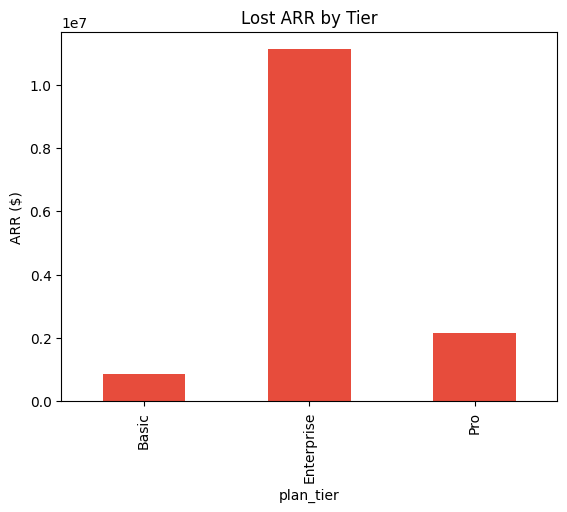

--- Q2: Churn Rate & Avg MRR/Seat by Billing Frequency ---
                   churn_rate  avg_mrr_per_seat
billing_frequency                              
annual               0.100366         76.843966
monthly              0.094132         76.638440




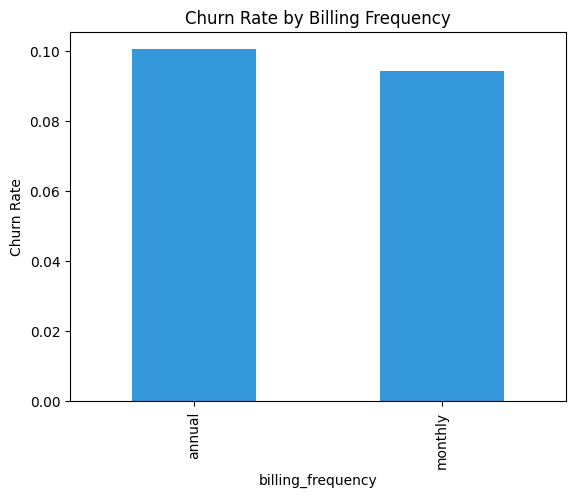

--- Q3: Total MRR by Cohort ---
cohort
Churned       1179139
Downgraded     435460
Unchanged     8585007
Upgraded      1139141
Name: mrr_amount, dtype: int64




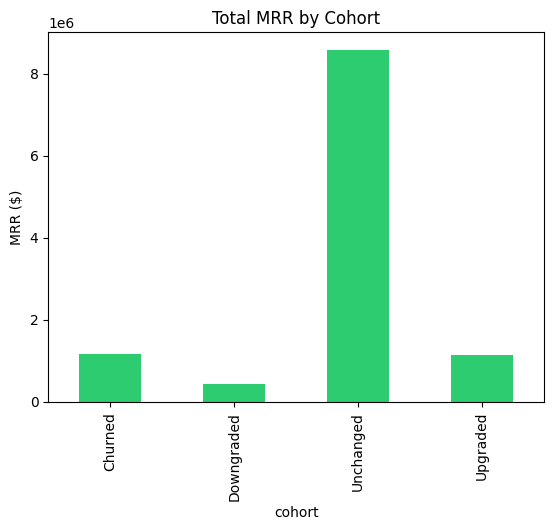

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('/content/ravenstack_subscriptions.csv')

# 2. Cleaning Layer
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])
# end_date nulls left as NaT for active subscriptions

# 3. Cohort Logic (Mutually Exclusive)
conditions = [
    df['churn_flag'] == True,
    df['downgrade_flag'] == True,
    df['upgrade_flag'] == True
]
choices = ['Churned', 'Downgraded', 'Upgraded']
df['cohort'] = np.select(conditions, choices, default='Unchanged')

# --- Q1: Churn concentration by tier ---
q1 = df[df['churn_flag'] == True].groupby('plan_tier')['arr_amount'].sum()
print("--- Q1: Lost ARR by Tier ---")
print(q1)
print("\n")
q1.plot(kind='bar', title='Lost ARR by Tier', ylabel='ARR ($)', color='#e74c3c')
plt.show()

# --- Q2: Annual vs Monthly churn and MRR per seat ---
df['mrr_per_seat'] = df['mrr_amount'] / df['seats']
q2 = df.groupby('billing_frequency').agg(
    churn_rate=('churn_flag', 'mean'),
    avg_mrr_per_seat=('mrr_per_seat', 'mean')
)
print("--- Q2: Churn Rate & Avg MRR/Seat by Billing Frequency ---")
print(q2)
print("\n")
q2['churn_rate'].plot(kind='bar', title='Churn Rate by Billing Frequency', ylabel='Churn Rate', color='#3498db')
plt.show()

# --- Q3: Total MRR currently held by cohorts ---
q3 = df.groupby('cohort')['mrr_amount'].sum()
print("--- Q3: Total MRR by Cohort ---")
print(q3)
print("\n")
q3.plot(kind='bar', title='Total MRR by Cohort', ylabel='MRR ($)', color='#2ecc71')
plt.show()

In [5]:
reference_date = df['start_date'].max()
df['tenure_days'] = (reference_date - df['start_date']).dt.days

print("--- Q2: Rata-rata Tenure (Hari) berdasarkan Billing Frequency ---")
print(df.groupby('billing_frequency')['tenure_days'].mean())

print("\n--- Q2: Tenure-Controlled Churn (Eksklusif >= 365 Hari) ---")
matched = df[df['tenure_days'] >= 365]
print(matched.groupby('billing_frequency')['churn_flag'].mean())

print("\n--- Q1: Churn Rate by Tier ---")
print(df.groupby('plan_tier')['churn_flag'].mean())

--- Q2: Rata-rata Tenure (Hari) berdasarkan Billing Frequency ---
billing_frequency
annual     169.641203
monthly    170.197716
Name: tenure_days, dtype: float64

--- Q2: Tenure-Controlled Churn (Eksklusif >= 365 Hari) ---
billing_frequency
annual     0.110448
monthly    0.141593
Name: churn_flag, dtype: float64

--- Q1: Churn Rate by Tier ---
plan_tier
Basic         0.094881
Enterprise    0.099826
Pro           0.096716
Name: churn_flag, dtype: float64
